In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the refined experiment csv file
df = pd.read_csv('swarm_foraging_experiment_refined_20260503_084559.csv')

# Display the first few rows to verify the columns
display(df.head())

,Unnamed: 0,RunId,iteration,Step,width,height,num_agents,pheromone_decay_rate,food_area_percentage,food_base_quantity,n_food_clusters,rng,Foraging,Returning,Resting,Alive,Dead (Energy),Dead (Temperature),Remaining Food (%)
0,0,0,0,0.0,60,60,40,0.01,0.15,10,12,NaN,40,0,0,40,0,0,100.0
1,1,0,0,1.0,60,60,40,0.01,0.15,10,12,NaN,40,0,0,40,0,0,100.0
2,2,0,0,2.0,60,60,40,0.01,0.15,10,12,NaN,40,0,0,40,0,0,100.0
3,3,0,0,3.0,60,60,40,0.01,0.15,10,12,NaN,40,0,0,40,0,0,100.0
4,4,0,0,4.0,60,60,40,0.01,0.15,10,12,NaN,40,0,0,40,0,0,100.0


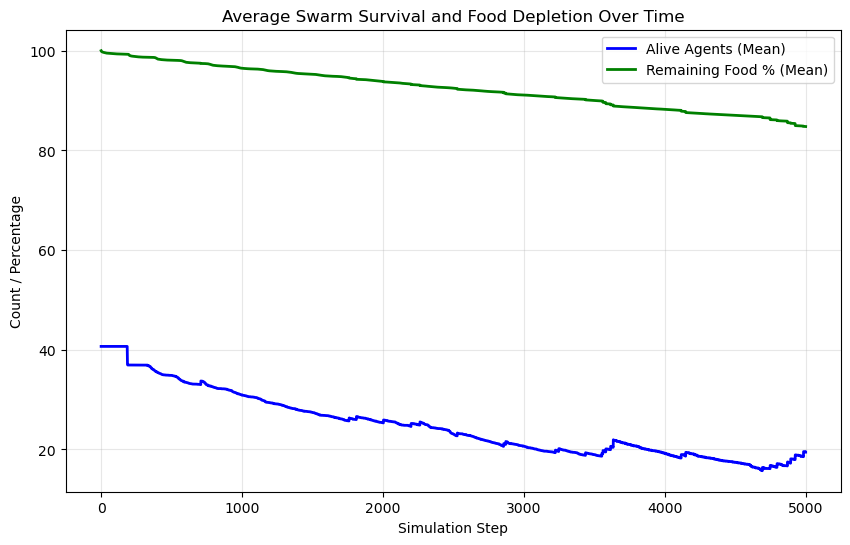

In [7]:
# Aggregate by Step, calculating the mean of key metrics across all runs
df_agg = df.groupby('Step').agg({
    'Alive': 'mean', 
    'Remaining Food (%)': 'mean'
}).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(df_agg['Step'], df_agg['Alive'], label='Alive Agents (Mean)', color='blue', linewidth=2)
plt.plot(df_agg['Step'], df_agg['Remaining Food (%)'], label='Remaining Food % (Mean)', color='green', linewidth=2)

plt.xlabel('Simulation Step')
plt.ylabel('Count / Percentage')
plt.title('Average Swarm Survival and Food Depletion Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Overall Swarm Status Over Time
This plot aggregates all simulation runs to show the general trend of agent survival and food consumption across the entire experiment.

# Impact of Swarm Size on Survival
Next, we separate the data by the number of agents (`num_agents`) to see if a slightly smaller or larger swarm improves the collective survival time. The shaded areas represent the standard deviation across iterations.

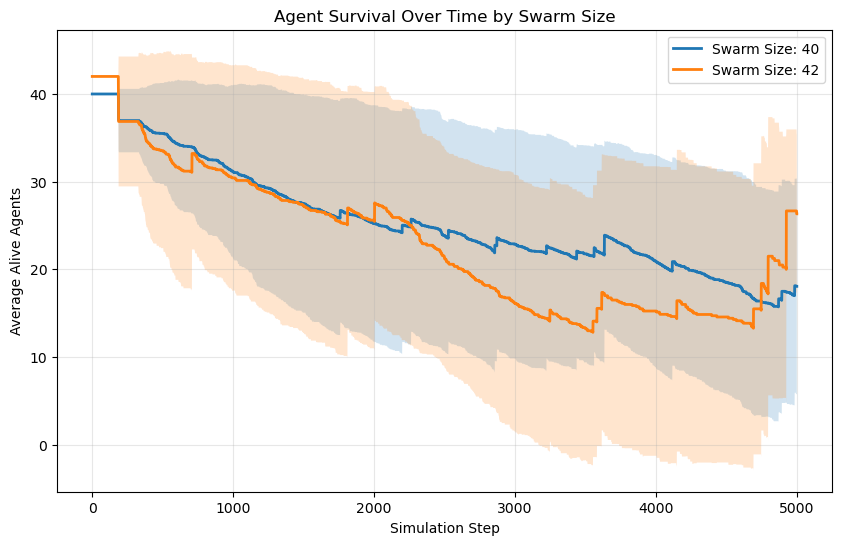

In [8]:
num_agents_list = df['num_agents'].unique()

plt.figure(figsize=(10, 6))
for num_agents in num_agents_list:
    df_subset = df[df['num_agents'] == num_agents]
    
    # Calculate mean and standard deviation for 'Alive' agents at each step
    mean_alive = df_subset.groupby('Step')['Alive'].mean()
    std_alive = df_subset.groupby('Step')['Alive'].std().fillna(0)
    steps = mean_alive.index
    
    plt.plot(steps, mean_alive, label=f'Swarm Size: {num_agents}', linewidth=2)
    # Add standard deviation as a shaded area
    plt.fill_between(steps, mean_alive - std_alive, mean_alive + std_alive, alpha=0.2)

plt.legend()
plt.xlabel('Simulation Step')
plt.ylabel('Average Alive Agents')
plt.title('Agent Survival Over Time by Swarm Size')
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# Find the maximum step reached (survival time) for each unique run
survival_times = df.groupby(['RunId', 'num_agents', 'pheromone_decay_rate'])['Step'].max().reset_index()

# Group by the parameters to see the average survival time
summary_table = survival_times.groupby(['num_agents', 'pheromone_decay_rate'])['Step'].mean().reset_index()
summary_table.rename(columns={'Step': 'Average Survival Time (Steps)'}, inplace=True)

display(summary_table.sort_values(by='Average Survival Time (Steps)', ascending=False))

,num_agents,pheromone_decay_rate,Average Survival Time (Steps)
0,40,0.01,4669.0
2,42,0.01,4231.5
1,40,0.03,3244.6
3,42,0.03,2902.0
